In [11]:
import sys
import numpy as np
from pathlib import Path
import os

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


In [2]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.config import processed_data_dir, models_dir, reports_dir, load_config


Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [4]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [5]:
# Inicializar TensorBoard
nombre_modelo = 'convolutional_autoencoder_model_optuna_2'
log_dir = reports_dir() / "logs"/ nombre_modelo

In [6]:
# Función para cargar los datos de un tag específico desde los logs de TensorBoard
def load_tensorboard_logs(log_dir, base_tag):
    all_steps = []
    all_values = []
    trial_ids = []

    # Recorremos todos los directorios de los trials
    for trial_dir in os.listdir(log_dir):
        trial_path = os.path.join(log_dir, trial_dir)

        # Verificamos si es un directorio y contiene eventos
        if os.path.isdir(trial_path):
            trial_id = trial_dir  # trial_id sería algo como 'trial_0', 'trial_1', etc.
            trial_tag = f"{trial_id}/{base_tag}"  # Crear el tag completo, por ejemplo, 'trial_0/Loss/val'

            for subdir, dirs, files in os.walk(trial_path):
                for file in files:
                    if file.startswith("events.out.tfevents"):
                        event_file = os.path.join(subdir, file)
                        event_acc = EventAccumulator(event_file)
                        event_acc.Reload()

                        # Verificamos si el tag con el identificador del trial está presente
                        if trial_tag in event_acc.Tags()['scalars']:
                            events = event_acc.Scalars(trial_tag)
                            steps = [e.step for e in events]
                            values = [e.value for e in events]

                            # Almacenar los pasos, valores y trial_ids
                            all_steps.append(steps)
                            all_values.append(values)
                            trial_ids.append(trial_id)

    return all_steps, all_values, trial_ids

In [7]:
# Elige el base_tag que deseas graficar, por ejemplo, 'Loss/val'
base_tag_to_plot = 'Loss/val'

In [9]:
# Cargar los logs
steps, values, trial_ids = load_tensorboard_logs(log_dir, base_tag_to_plot)

In [12]:
# Calcular la pérdida mínima de cada trial para ordenarlas
min_losses = [min(val) for val in values]
sorted_indices = np.argsort(min_losses)

In [13]:
# Seleccionar los índices de las curvas: la de menor pérdida, la de mayor pérdida y 6 intermedias
num_curves_to_plot = 8  # Cambia esto si quieres más o menos curvas intermedias
selected_indices = np.concatenate((
    [sorted_indices[0]],  # Menor pérdida
    [sorted_indices[-1]],  # Mayor pérdida
    sorted_indices[1:7]  # 6 intermedias
))

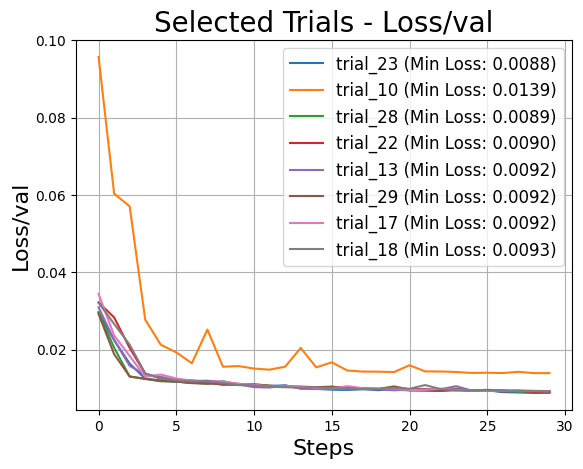

In [15]:
# Graficar los trials seleccionados
for i in selected_indices:
    plt.plot(steps[i], values[i], label=f'{trial_ids[i]} (Min Loss: {min_losses[i]:.4f})')

plt.xlabel("Steps", fontsize=16)
plt.ylabel(base_tag_to_plot, fontsize=16)
plt.title(f"Selected Trials - {base_tag_to_plot}", fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()